# 20cm -> 30 cm
## f = 1.5 Hz -> f = 1.225 Hz

Scaling from 20cm to 30cm - f15_a01

*Wave parameters at 20cm:*
* Frequency (Hz): 1.5
* Angular frequency (rad/s): 9.42477796076938
* Amplitude at P0 (m): 0.0065
* Wave number (1/m): 9.4736
* Wavelength (m): 0.6632
* ak value at 20cm: 0.06157839999999999
* kH value at 20cm: 1.89472
* **A(V) = 0.1 V**

*Scaled wave parameters at 30cm:*
* Frequency (Hz): 1.2247448713915892
* Angular frequency (rad/s): 7.6952989809711845
* Amplitude at P0 (m): 0.009749999999999998
* Wave number (1/m): 6.315733333333333
* Wavelength (m): 0.9948465167169165
* ak value at 30cm: 0.061578399999999985
* kH value at 30cm: 1.89472
* **A(V) = 0.152 V**

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score

sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')

from funcs import *
from processing_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_190126/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
# For plotting
freq1 = 1.5
freq2 = 1.225

target_amp = 0.00975

In [55]:
# Opening the raw files
r1_20_raw = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Kjersti_190126/No_plates/20cm/f15/a01/f15a01h02r1.csv')
r2_20_raw = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Kjersti_190126/No_plates/20cm/f15/a01/f15a01h02r2.csv')
r3_20_raw = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Kjersti_190126/No_plates/20cm/f15/a01/f15a01h02r3.csv')

r1_30_raw = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Kjersti_190126/No_plates/30cm/f1225/a0152/f1225a0152h03r1.csv')
r2_30_raw = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Kjersti_190126/No_plates/30cm/f1225/a0152/f1225a0152h03r2.csv')
r3_30_raw = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Kjersti_190126/No_plates/30cm/f1225/a0152/f1225a0152h03r3.csv')

headers = ['time', 'P_0', 'P_1', 'P_2', 'P_3', 'sound_speed']

r1_20_raw.columns = headers
r2_20_raw.columns = headers
r3_20_raw.columns = headers

r1_30_raw.columns = headers
r2_30_raw.columns = headers
r3_30_raw.columns = headers

In [56]:
# Post-processing

r1_20_cl = clean(r1_20_raw)
r2_20_cl = clean(r2_20_raw)
r3_20_cl = clean(r3_20_raw)

r1_30_cl = clean(r1_30_raw)
r2_30_cl = clean(r2_30_raw)
r3_30_cl = clean(r3_30_raw)

In [57]:
# Positions of probes
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])  # Base positions, meters from wave maker

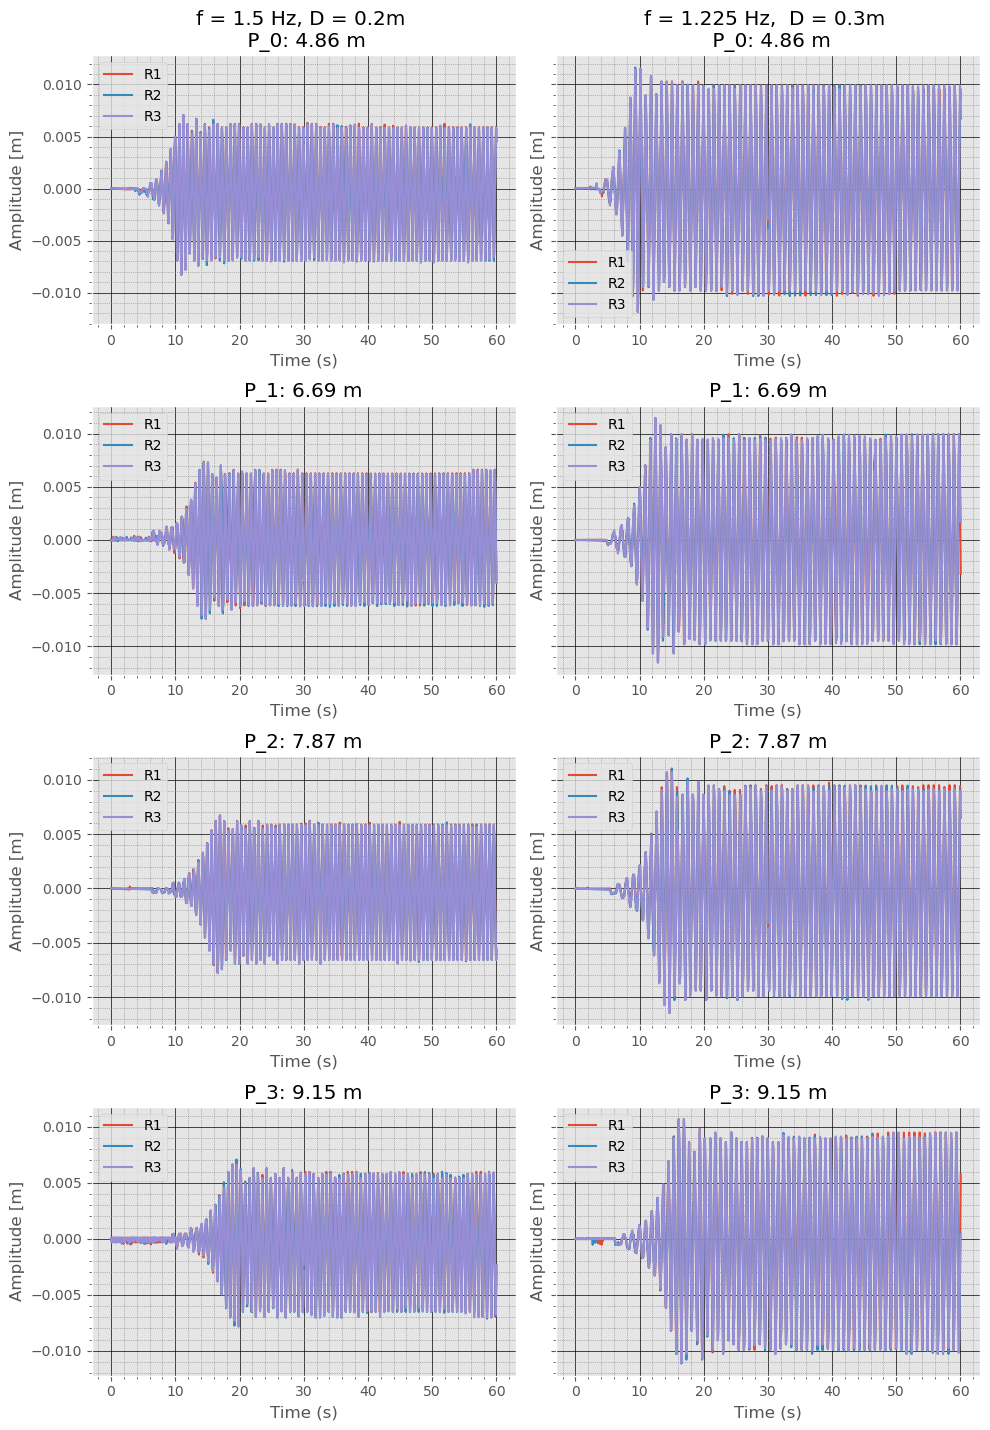

In [58]:
fig, ax = plt.subplots(4,2, figsize=(10, 15), sharey='row')

# P0
ax[0, 0].plot(r1_20_cl['time'], r1_20_cl['P_0'], label='R1')
ax[0,0].plot(r2_20_cl['time'], r2_20_cl['P_0'], label='R2')
ax[0,0].plot(r3_20_cl['time'], r3_20_cl['P_0'], label='R3')

# P1
ax[1,0].plot(r1_20_cl['time'], r1_20_cl['P_1'], label='R1')
ax[1,0].plot(r2_20_cl['time'], r2_20_cl['P_1'], label='R2')
ax[1,0].plot(r3_20_cl['time'], r3_20_cl['P_1'], label='R3')

# P2
ax[2,0].plot(r1_20_cl['time'], r1_20_cl['P_2'], label='R1')
ax[2,0].plot(r2_20_cl['time'], r2_20_cl['P_2'], label='R2')
ax[2,0].plot(r3_20_cl['time'], r3_20_cl['P_2'], label='R3')

# P3
ax[3,0].plot(r1_20_cl['time'], r1_20_cl['P_3'], label='R1')
ax[3,0].plot(r2_20_cl['time'], r2_20_cl['P_3'], label='R2')
ax[3,0].plot(r3_20_cl['time'], r3_20_cl['P_3'], label='R3')

# P0
ax[0,1].plot(r1_30_cl['time'], r1_30_cl['P_0'], label='R1')
ax[0,1].plot(r2_30_cl['time'], r2_30_cl['P_0'], label='R2')
ax[0,1].plot(r3_30_cl['time'], r3_30_cl['P_0'], label='R3')

# P1
ax[1,1].plot(r1_30_cl['time'], r1_30_cl['P_1'], label='R1')
ax[1,1].plot(r2_30_cl['time'], r2_30_cl['P_1'], label='R2')
ax[1,1].plot(r3_30_cl['time'], r3_30_cl['P_1'], label='R3')

# P2
ax[2,1].plot(r1_30_cl['time'], r1_30_cl['P_2'], label='R1')
ax[2,1].plot(r2_30_cl['time'], r2_30_cl['P_2'], label='R2')
ax[2,1].plot(r3_30_cl['time'], r3_30_cl['P_2'], label='R3')

# P3
ax[3,1].plot(r1_30_cl['time'], r1_30_cl['P_3'], label='R1')
ax[3,1].plot(r2_30_cl['time'], r2_30_cl['P_3'], label='R2')
ax[3,1].plot(r3_30_cl['time'], r3_30_cl['P_3'], label='R3')

for axs in ax.flatten():
    axs.grid(which='major', linestyle='-', linewidth='0.5', color='black')
    axs.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    axs.legend()
    axs.set_xlabel('Time (s)')
    axs.set_ylabel('Amplitude [m]')
    axs.minorticks_on()

ax[0, 0].set_title(f'f = {freq1} Hz, D = 0.2m \n P_0: {x_probe_pos[0]} m')
ax[1, 0].set_title(f'P_1: {x_probe_pos[1]} m')
ax[2, 0].set_title(f'P_2: {x_probe_pos[2]} m')
ax[3, 0].set_title(f'P_3: {x_probe_pos[3]} m')

ax[0, 1].set_title(f'f = {freq2} Hz,  D = 0.3m \n P_0: {x_probe_pos[0]} m')
ax[1, 1].set_title(f'P_1: {x_probe_pos[1]} m')
ax[2, 1].set_title(f'P_2: {x_probe_pos[2]} m')
ax[3, 1].set_title(f'P_3: {x_probe_pos[3]} m')

plt.tight_layout(rect=[0, 0, 1, 0.96])

In [59]:
""" # If needed, correct outliers and interpolate missing data
threshold = 0.0005  # Set threshold for spike detection

r1_20_corr = correct_spikes(r1_20_cl, threshold)
r2_20_corr = correct_spikes(r2_20_cl, threshold)
r3_20_corr = correct_spikes(r3_20_cl, threshold)

r2_30_corr = correct_spikes(r2_30_cl, threshold)
r3_30_corr = correct_spikes(r3_30_cl, threshold)
r1_30_corr = correct_spikes(r1_30_cl, threshold) """

' # If needed, correct outliers and interpolate missing data\nthreshold = 0.0005  # Set threshold for spike detection\n\nr1_20_corr = correct_spikes(r1_20_cl, threshold)\nr2_20_corr = correct_spikes(r2_20_cl, threshold)\nr3_20_corr = correct_spikes(r3_20_cl, threshold)\n\nr2_30_corr = correct_spikes(r2_30_cl, threshold)\nr3_30_corr = correct_spikes(r3_30_cl, threshold)\nr1_30_corr = correct_spikes(r1_30_cl, threshold) '

In [60]:
r1_20 = detrend(r1_20_cl)
r2_20 = detrend(r2_20_cl)
r3_20 = detrend(r3_20_cl)

r1_30 = detrend(r1_30_cl)
r2_30 = detrend(r2_30_cl)
r3_30 = detrend(r3_30_cl)

# Checking that all probes now have zero mean (still water level)
for col in ['P_0', 'P_1', 'P_2', 'P_3']:
    print(np.mean(r1_20[col]), np.mean(r1_30[col]))
    print(np.mean(r2_20[col]), np.mean(r2_30[col]))
    print(np.mean(r3_20[col]), np.mean(r3_30[col]))

4.0708177569589074e-20 7.543481782025444e-19
-6.514176968063327e-19 -7.957659364395541e-19
3.848516584261592e-19 -1.8506184568361723e-20
6.254256372055048e-19 -1.5530697786522974e-19
-5.514843001371794e-19 -2.998001900074599e-19
4.329581157294291e-19 -7.883634626122094e-19
-1.942890293094024e-19 4.973521076874619e-19
6.292102753242986e-19 -9.068030438497245e-19
-3.6634917484797844e-19 1.5545195037423848e-19
1.905882858939852e-19 8.726773041951004e-19
9.253092284180862e-20 -1.1103710741017035e-19
-1.7392334563489886e-19 3.22007611489494e-19


In [61]:
# Cut off initial wave maker build-up time and parts that contain reflections
wave_maker_build_up_time = 14

r1_20 = cut_out_valid_data(r1_20, freq1, 0.2, wave_maker_build_up_time, x_probe_pos)
r2_20 = cut_out_valid_data(r2_20, freq1, 0.2, wave_maker_build_up_time, x_probe_pos)
r3_20 = cut_out_valid_data(r3_20, freq1, 0.2, wave_maker_build_up_time, x_probe_pos)

r1_30 = cut_out_valid_data(r1_30, freq2, 0.3, wave_maker_build_up_time, x_probe_pos)
r2_30 = cut_out_valid_data(r2_30, freq2, 0.3, wave_maker_build_up_time, x_probe_pos)
r3_30 = cut_out_valid_data(r3_30, freq2, 0.3, wave_maker_build_up_time, x_probe_pos)

----- Cutting out invalid data -----
Time after transient front reaches each probe: [14.         19.27160494 22.67078189 26.35802469]

Reflection arrival times at each probe: [69.12649754 62.84539077 58.7952782  54.40193575]

Time window between build-up and reflection at each probe: [55.12649754 43.57378583 36.12449631 28.04391106]

Maximum number of usable wave periods at each probe: [82.68974632 65.36067874 54.18674446 42.06586659]
-------------------------------------------------
----- Cutting out invalid data -----
Time after transient front reaches each probe: [14.         19.27160494 22.67078189 26.35802469]

Reflection arrival times at each probe: [69.12649754 62.84539077 58.7952782  54.40193575]

Time window between build-up and reflection at each probe: [55.12649754 43.57378583 36.12449631 28.04391106]

Maximum number of usable wave periods at each probe: [82.68974632 65.36067874 54.18674446 42.06586659]
-------------------------------------------------
----- Cutting out inva

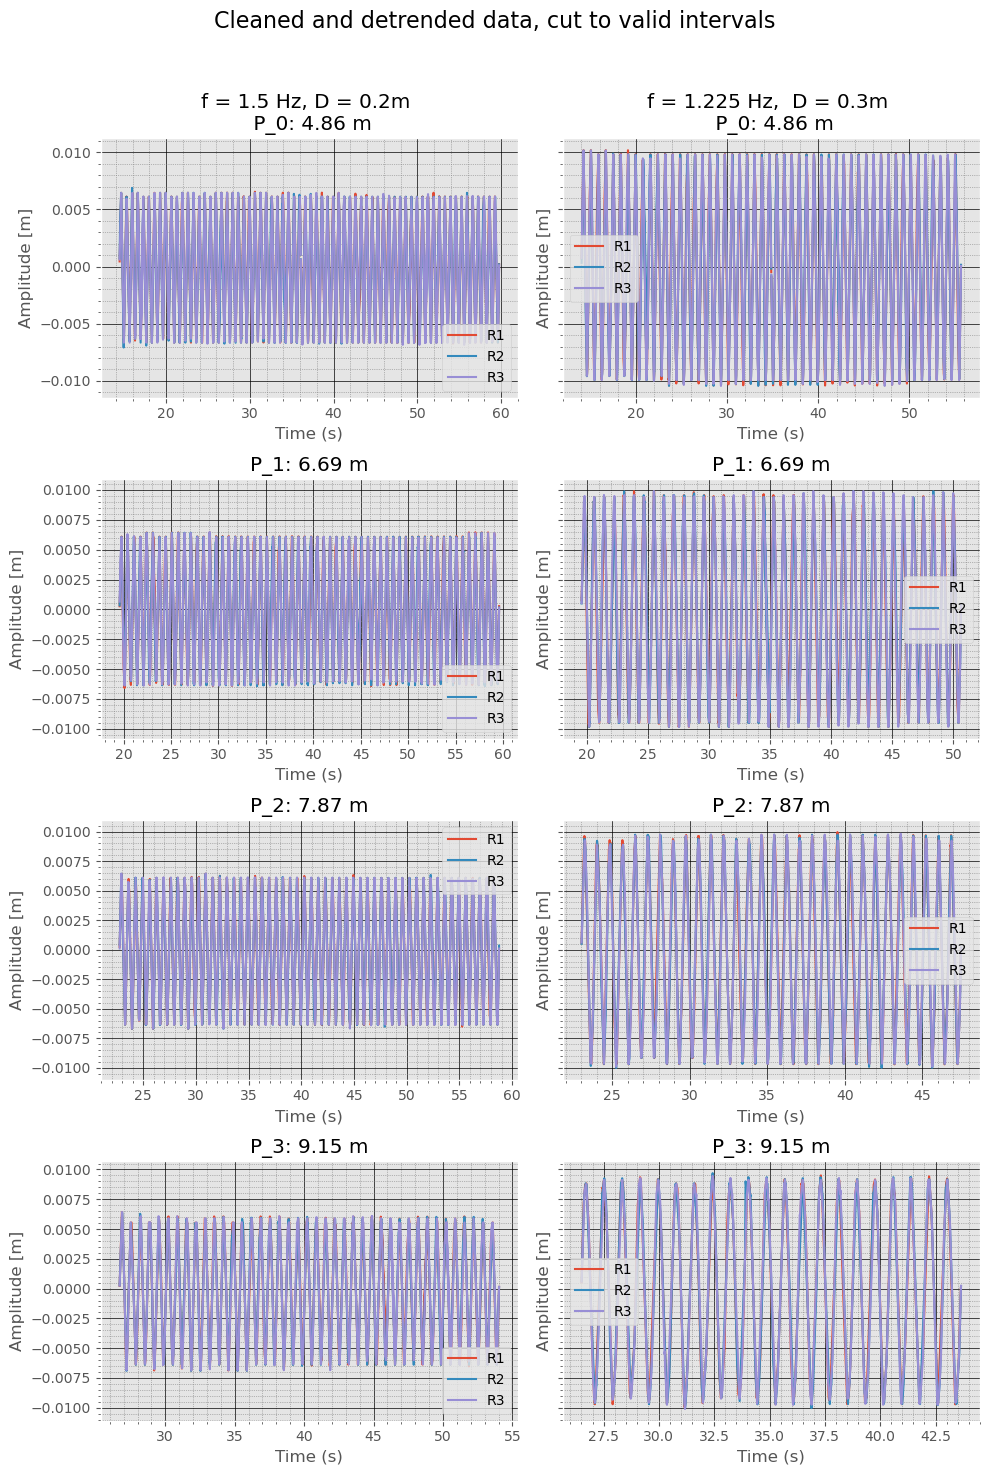

In [62]:
fig, ax = plt.subplots(4,2, figsize=(10, 15), sharey='row')

# P0
ax[0, 0].plot(r1_20['time'], r1_20['P_0'], label='R1')
ax[0,0].plot(r2_20['time'], r2_20['P_0'], label='R2')
ax[0,0].plot(r3_20['time'], r3_20['P_0'], label='R3')

# P1
ax[1,0].plot(r1_20['time'], r1_20['P_1'], label='R1')
ax[1,0].plot(r2_20['time'], r2_20['P_1'], label='R2')
ax[1,0].plot(r3_20['time'], r3_20['P_1'], label='R3')

# P2
ax[2,0].plot(r1_20['time'], r1_20['P_2'], label='R1')
ax[2,0].plot(r2_20['time'], r2_20['P_2'], label='R2')
ax[2,0].plot(r3_20['time'], r3_20['P_2'], label='R3')

# P3
ax[3,0].plot(r1_20['time'], r1_20['P_3'], label='R1')
ax[3,0].plot(r2_20['time'], r2_20['P_3'], label='R2')
ax[3,0].plot(r3_20['time'], r3_20['P_3'], label='R3')

# P0
ax[0,1].plot(r1_30['time'], r1_30['P_0'], label='R1')
ax[0,1].plot(r2_30['time'], r2_30['P_0'], label='R2')
ax[0,1].plot(r3_30['time'], r3_30['P_0'], label='R3')

# P1
ax[1,1].plot(r1_30['time'], r1_30['P_1'], label='R1')
ax[1,1].plot(r2_30['time'], r2_30['P_1'], label='R2')
ax[1,1].plot(r3_30['time'], r3_30['P_1'], label='R3')

# P2
ax[2,1].plot(r1_30['time'], r1_30['P_2'], label='R1')
ax[2,1].plot(r2_30['time'], r2_30['P_2'], label='R2')
ax[2,1].plot(r3_30['time'], r3_30['P_2'], label='R3')

# P3
ax[3,1].plot(r1_30['time'], r1_30['P_3'], label='R1')
ax[3,1].plot(r2_30['time'], r2_30['P_3'], label='R2')
ax[3,1].plot(r3_30['time'], r3_30['P_3'], label='R3')

for axs in ax.flatten():
    axs.grid(which='major', linestyle='-', linewidth='0.5', color='black')
    axs.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    axs.legend()
    axs.set_xlabel('Time (s)')
    axs.set_ylabel('Amplitude [m]')
    axs.minorticks_on()

ax[0, 0].set_title(f'f = {freq1} Hz, D = 0.2m \n P_0: {x_probe_pos[0]} m')
ax[1, 0].set_title(f'P_1: {x_probe_pos[1]} m')
ax[2, 0].set_title(f'P_2: {x_probe_pos[2]} m')
ax[3, 0].set_title(f'P_3: {x_probe_pos[3]} m')

ax[0, 1].set_title(f'f = {freq2} Hz,  D = 0.3m \n P_0: {x_probe_pos[0]} m')
ax[1, 1].set_title(f'P_1: {x_probe_pos[1]} m')
ax[2, 1].set_title(f'P_2: {x_probe_pos[2]} m')
ax[3, 1].set_title(f'P_3: {x_probe_pos[3]} m')

fig.suptitle('Cleaned and detrended data, cut to valid intervals', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])

In [63]:
# Calculating standard deviations and amplitudes for probe 0 - per run and depth
std_R1_20_P0 = np.std(r1_20['P_0'])
std_R2_20_P0 = np.std(r2_20['P_0'])
std_R3_20_P0 = np.std(r3_20['P_0'])

std_R1_30_P0 = np.std(r1_30['P_0'])
std_R2_30_P0 = np.std(r2_30['P_0'])
std_R3_30_P0 = np.std(r3_30['P_0'])

amp_R1_20_P0 = std_R1_20_P0 * np.sqrt(2)
amp_R2_20_P0 = std_R2_20_P0 * np.sqrt(2)
amp_R3_20_P0 = std_R3_20_P0 * np.sqrt(2)

amp_R1_30_P0 = std_R1_30_P0 * np.sqrt(2)
amp_R2_30_P0 = std_R2_30_P0 * np.sqrt(2)
amp_R3_30_P0 = std_R3_30_P0 * np.sqrt(2)

In [64]:
# Calculating standard deviations and amplitudes for probe 1 - per run and depth
std_R1_20_P1 = np.std(r1_20['P_1'])
std_R2_20_P1 = np.std(r2_20['P_1'])
std_R3_20_P1 = np.std(r3_20['P_1'])

std_R1_30_P1 = np.std(r1_30['P_1'])
std_R2_30_P1 = np.std(r2_30['P_1'])
std_R3_30_P1 = np.std(r3_30['P_1'])

amp_R1_20_P1 = std_R1_20_P1 * np.sqrt(2)
amp_R2_20_P1 = std_R2_20_P1 * np.sqrt(2)
amp_R3_20_P1 = std_R3_20_P1 * np.sqrt(2)

amp_R1_30_P1 = std_R1_30_P1 * np.sqrt(2)
amp_R2_30_P1 = std_R2_30_P1 * np.sqrt(2)
amp_R3_30_P1 = std_R3_30_P1 * np.sqrt(2)

In [65]:
# Calculating standard deviations and amplitudes for probe 2 - per run and depth
std_R1_20_P2 = np.std(r1_20['P_2'])
std_R2_20_P2 = np.std(r2_20['P_2'])
std_R3_20_P2 = np.std(r3_20['P_2'])

std_R1_30_P2 = np.std(r1_30['P_2'])
std_R2_30_P2 = np.std(r2_30['P_2'])
std_R3_30_P2 = np.std(r3_30['P_2'])

amp_R1_20_P2 = std_R1_20_P2 * np.sqrt(2)
amp_R2_20_P2 = std_R2_20_P2 * np.sqrt(2)
amp_R3_20_P2 = std_R3_20_P2 * np.sqrt(2)

amp_R1_30_P2 = std_R1_30_P2 * np.sqrt(2)
amp_R2_30_P2 = std_R2_30_P2 * np.sqrt(2)
amp_R3_30_P2 = std_R3_30_P2 * np.sqrt(2)

In [66]:
# Calculating standard deviations and amplitudes for probe 3 - per run and depth
std_R1_20_P3 = np.std(r1_20['P_3'])
std_R2_20_P3 = np.std(r2_20['P_3'])
std_R3_20_P3 = np.std(r3_20['P_3'])

std_R1_30_P3 = np.std(r1_30['P_3'])
std_R2_30_P3 = np.std(r2_30['P_3'])
std_R3_30_P3 = np.std(r3_30['P_3'])

amp_R1_20_P3 = std_R1_20_P3 * np.sqrt(2)
amp_R2_20_P3 = std_R2_20_P3 * np.sqrt(2)
amp_R3_20_P3 = std_R3_20_P3 * np.sqrt(2)

amp_R1_30_P3 = std_R1_30_P3 * np.sqrt(2)
amp_R2_30_P3 = std_R2_30_P3 * np.sqrt(2)
amp_R3_30_P3 = std_R3_30_P3 * np.sqrt(2)

In [67]:
amps_20_R1 = [amp_R1_20_P0, amp_R1_20_P1, amp_R1_20_P2, amp_R1_20_P3]
amps_20_R2 = [amp_R2_20_P0, amp_R2_20_P1, amp_R2_20_P2, amp_R2_20_P3]
amps_20_R3 = [amp_R3_20_P0, amp_R3_20_P1, amp_R3_20_P2, amp_R3_20_P3]

amps_30_R1 = [amp_R1_30_P0, amp_R1_30_P1, amp_R1_30_P2, amp_R1_30_P3]
amps_30_R2 = [amp_R2_30_P0, amp_R2_30_P1, amp_R2_30_P2, amp_R2_30_P3]
amps_30_R3 = [amp_R3_30_P0, amp_R3_30_P1, amp_R3_30_P2, amp_R3_30_P3]

# Mean amplitudes per probe over the three runs
mean_amp_20_P0 = np.mean([amp_R1_20_P0, amp_R2_20_P0, amp_R3_20_P0])
mean_amp_30_P0 = np.mean([amp_R1_30_P0, amp_R2_30_P0, amp_R3_30_P0])

mean_amp_20_P1 = np.mean([amp_R1_20_P1, amp_R2_20_P1, amp_R3_20_P1])
mean_amp_30_P1 = np.mean([amp_R1_30_P1, amp_R2_30_P1, amp_R3_30_P1])

mean_amp_20_P2 = np.mean([amp_R1_20_P2, amp_R2_20_P2, amp_R3_20_P2])
mean_amp_30_P2 = np.mean([amp_R1_30_P2, amp_R2_30_P2, amp_R3_30_P2])

mean_amp_20_P3 = np.mean([amp_R1_20_P3, amp_R2_20_P3, amp_R3_20_P3])
mean_amp_30_P3 = np.mean([amp_R1_30_P3, amp_R2_30_P3, amp_R3_30_P3])

# Gathering mean amplitudes into lists for easier plotting later
amps_20 = [mean_amp_20_P0, mean_amp_20_P1, mean_amp_20_P2, mean_amp_20_P3]
amps_30 = [mean_amp_30_P0, mean_amp_30_P1, mean_amp_30_P2, mean_amp_30_P3]

In [68]:
# Standard error
errors_20 = []
errors_20.append(np.mean([std_R1_20_P0, std_R2_20_P0, std_R3_20_P0]) / np.sqrt(np.mean([len(r1_20['P_0']), len(r2_20['P_0']), len(r3_20['P_0'])])))
errors_20.append(np.mean([std_R1_20_P1, std_R2_20_P1, std_R3_20_P1]) / np.sqrt(np.mean([len(r1_20['P_1']), len(r2_20['P_1']), len(r3_20['P_1'])])))
errors_20.append(np.mean([std_R1_20_P2, std_R2_20_P2, std_R3_20_P2]) / np.sqrt(np.mean([len(r1_20['P_2']), len(r2_20['P_2']), len(r3_20['P_2'])])))
errors_20.append(np.mean([std_R1_20_P3, std_R2_20_P3, std_R3_20_P3]) / np.sqrt(np.mean([len(r1_20['P_3']), len(r2_20['P_3']), len(r3_20['P_3'])])))

In [69]:
# Standard error
errors_30 = []
errors_30.append(np.mean([std_R1_30_P0, std_R2_30_P0, std_R3_30_P0]) / np.sqrt(np.mean([len(r1_30['P_0']), len(r2_30['P_0']), len(r3_30['P_0'])])))
errors_30.append(np.mean([std_R1_30_P1, std_R2_30_P1, std_R3_30_P1]) / np.sqrt(np.mean([len(r1_30['P_1']), len(r2_30['P_1']), len(r3_30['P_1'])])))
errors_30.append(np.mean([std_R1_30_P2, std_R2_30_P2, std_R3_30_P2]) / np.sqrt(np.mean([len(r1_30['P_2']), len(r2_30['P_2']), len(r3_30['P_2'])])))
errors_30.append(np.mean([std_R1_30_P3, std_R2_30_P3, std_R3_30_P3]) / np.sqrt(np.mean([len(r1_30['P_3']), len(r2_30['P_3']), len(r3_30['P_3'])])))

In [70]:
# Linear regression of amplitude vs probe position
coeff_20 = np.polyfit(x_probe_pos, amps_20, 1)  
line_20 = np.poly1d(coeff_20)           
r2_score_20 = r2_score(amps_20, line_20(x_probe_pos))

coeff_30 = np.polyfit(x_probe_pos, amps_30, 1)  
line_30 = np.poly1d(coeff_30)           
r2_score_30 = r2_score(amps_30, line_30(x_probe_pos))

Text(0.5, 0.98, 'Amplitude vs Probe Position with Linear Fit')

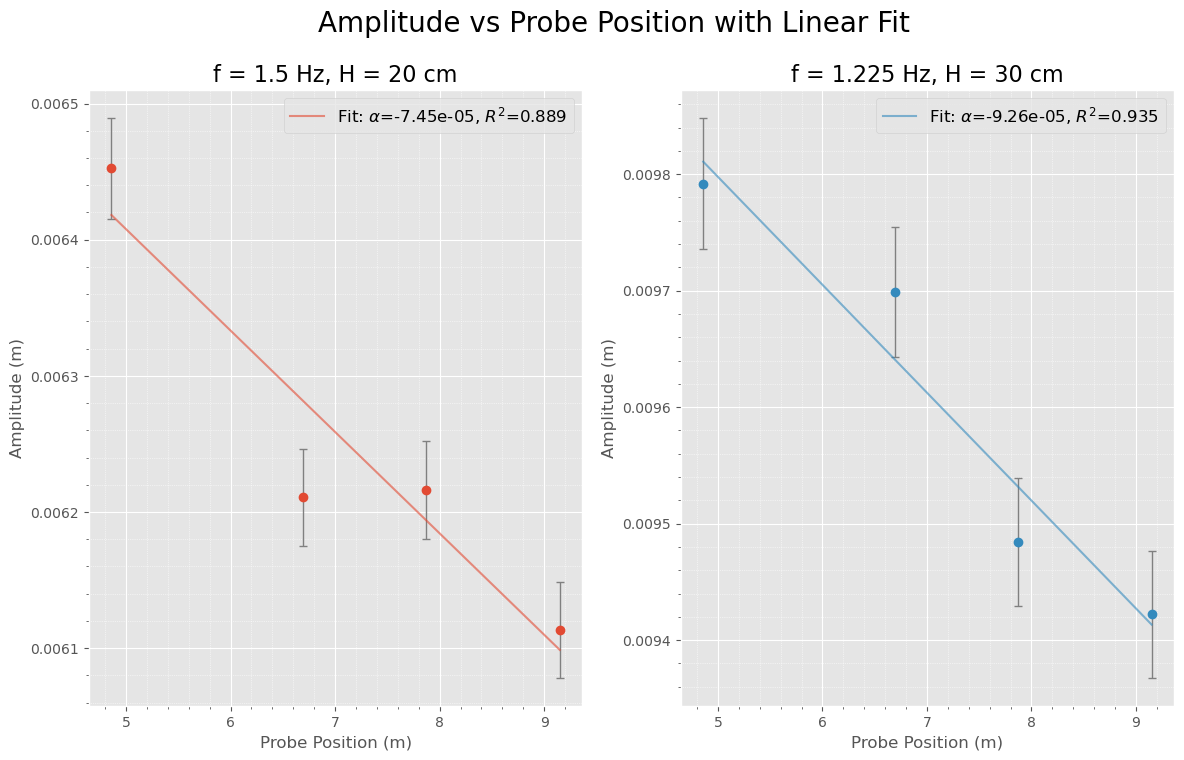

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(14, 8))

ax[0].errorbar(x_probe_pos,
            amps_20,
            yerr=errors_20,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

ax[1].errorbar(x_probe_pos,
            amps_30,
            mfc = 'C1',
            mec = 'C1',
            yerr=errors_30,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[0].plot(xx, line_20(xx), color= 'C0', alpha=0.6,
         label=rf'Fit: $\alpha$={coeff_20[0]:.2e}, $R^2$={r2_score_20:.3f}')

ax[1].plot(xx, line_30(xx), color= 'C1', alpha=0.6,
         label=rf'Fit: $\alpha$={coeff_30[0]:.2e}, $R^2$={r2_score_30:.3f}')

ax[0].grid(which='minor', linestyle=':', linewidth='0.5', color='white')
ax[0].minorticks_on()

ax[1].grid(which='minor', linestyle=':', linewidth='0.5', color='white')
ax[1].minorticks_on()

ax[0].set_xlabel('Probe Position (m)', fontsize=12)
ax[0].set_ylabel('Amplitude (m)', fontsize=12)
ax[0].set_title(f'f = {freq1} Hz, H = 20 cm', fontsize=16)
ax[0].legend(fontsize=12)

ax[1].set_xlabel('Probe Position (m)', fontsize=12)
ax[1].set_ylabel('Amplitude (m)', fontsize=12)
ax[1].set_title(f'f = {freq2} Hz, H = 30 cm', fontsize=16)
ax[1].legend(fontsize=12)

fig.suptitle('Amplitude vs Probe Position with Linear Fit', fontsize=20)

In [72]:
k_20 = estimate_wavenumber(freq1, 0.2)
k_30 = estimate_wavenumber(freq2, 0.3)

ak_20_P0 = mean_amp_20_P0 * k_20
ak_30_P0 = mean_amp_30_P0 * k_30

kh_20 = k_20 * 0.2
kh_30 = k_30 * 0.3

In [73]:
# Decay rate
amp_change_20 = amps_20[0] - amps_20[-1]
amp_change_30 = amps_30[0] - amps_30[-1]

decay_rate_20 = amp_change_20 / (x_probe_pos[-1] - x_probe_pos[0])
decay_rate_30 = amp_change_30 / (x_probe_pos[-1] - x_probe_pos[0])

In [74]:
print("Summary of results:")
print()
print(f"20 cm water depth:\n")
print(f'Amplitude at P0: {mean_amp_20_P0:.4f} m')
print(f'ak = {ak_20_P0:.4f}, kH = {kh_20:.4f}')
print(f"Amplitude change: {amp_change_20:.4f} m")
print(f"Decay rate: {decay_rate_20:.4f} m/m")
print('-------------------------')
print(f"30 cm water depth:\n")
print(f'Target ampltude at P0: {target_amp:.5f} m')
print(f'Observed amplitude at P0: {mean_amp_30_P0:.4f} m')
print(f'ak = {ak_30_P0:.4f}, kH = {kh_30:.4f}')
print(f"Amplitude change: {amp_change_30:.4f} m")
print(f"Decay rate: {decay_rate_30:.4f} m/m")
print('-------------------------')
print(f'% difference from target amplitude at P0: {((mean_amp_30_P0 - target_amp) / target_amp) * 100:.4f} %')
print(f'% difference in ak: {((ak_30_P0 - (target_amp * k_30)) / (target_amp * k_30)) * 100:.4f} %')
print(f'% difference in kH: {((kh_30 - (k_30 * 0.3)) / (k_30 * 0.3)) * 100:.4f} %')

Summary of results:

20 cm water depth:

Amplitude at P0: 0.0065 m
ak = 0.0611, kH = 1.8947
Amplitude change: 0.0003 m
Decay rate: 0.0001 m/m
-------------------------
30 cm water depth:

Target ampltude at P0: 0.00975 m
Observed amplitude at P0: 0.0098 m
ak = 0.0619, kH = 1.8954
Amplitude change: 0.0004 m
Decay rate: 0.0001 m/m
-------------------------
% difference from target amplitude at P0: 0.4294 %
% difference in ak: 0.4294 %
% difference in kH: 0.0000 %


## Comparing the experiments across depth by nondimensionalization

In [75]:
def make_dimensionless(eta, depth, t):
    """
    Convert amplitude to dimensionless form.
    """
    eta_star = eta / depth 
    t_star = np.sqrt(9.81 / depth) * t
    
    return eta_star, t_star

Text(0.5, 0.98, 'Dimensionless Surface Elevation at Probe 0 for Both Depths')

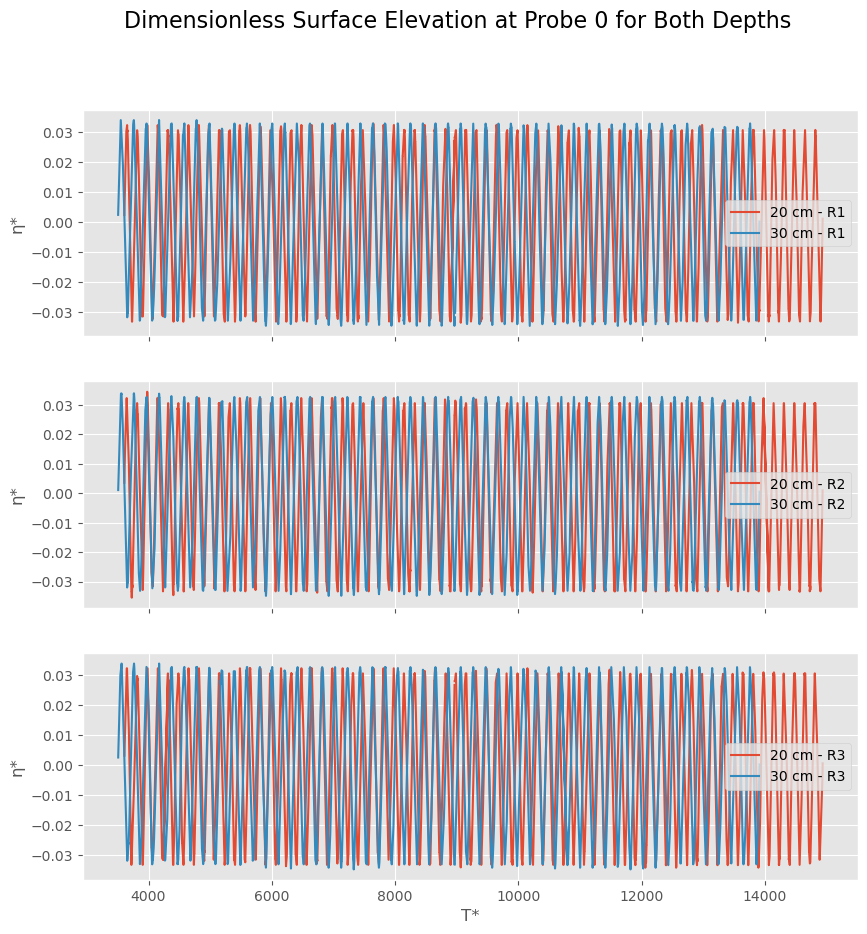

In [76]:
eta_non_20_R1_P0, t_non_20 = make_dimensionless(r1_20['P_0'], 0.2, r1_20['time'])
eta_non_30_R1_P0, t_non_30 = make_dimensionless(r1_30['P_0'], 0.3, r1_30['time'])

eta_non_20_R2_P0, _ = make_dimensionless(r2_20['P_0'], 0.2, r2_20['time'])
eta_non_30_R2_P0, _ = make_dimensionless(r2_30['P_0'], 0.3, r2_30['time'])

eta_non_20_R3_P0, _ = make_dimensionless(r3_20['P_0'], 0.2, r3_20['time'])
eta_non_30_R3_P0, _ = make_dimensionless(r3_30['P_0'], 0.3, r3_30['time'])

fig, ax = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

ax[0].plot(eta_non_20_R1_P0, label='20 cm - R1')
ax[0].plot(eta_non_30_R1_P0, label='30 cm - R1')

ax[1].plot(eta_non_20_R2_P0, label='20 cm - R2')
ax[1].plot(eta_non_30_R2_P0, label='30 cm - R2')

ax[2].plot(eta_non_20_R3_P0, label='20 cm - R3')
ax[2].plot(eta_non_30_R3_P0, label='30 cm - R3')

ax[0].legend()
ax[1].legend()
ax[2].legend()

ax[2].set_xlabel('T*')
ax[0].set_ylabel('η*')
ax[1].set_ylabel('η*')
ax[2].set_ylabel('η*')

fig.suptitle('Dimensionless Surface Elevation at Probe 0 for Both Depths', fontsize=16)

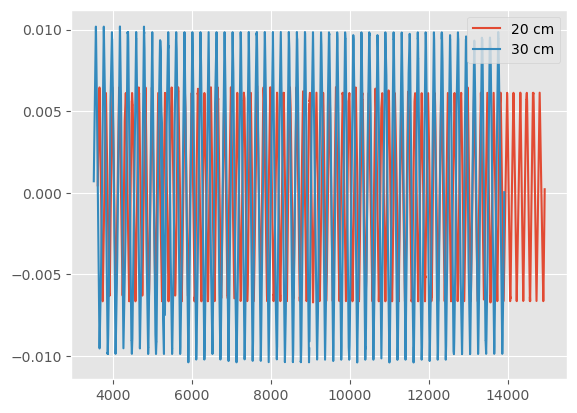

In [77]:
plt.plot(r1_20['P_0'], label='20 cm')
plt.plot(r1_30['P_0'], label='30 cm')

plt.legend()

In [78]:
np.std(r1_30['P_0'])/np.std(r1_20['P_0'])

1.5212961490341326